All libraries loaded successfully.
Dataset shape: (294, 14)
Target distribution:
target
No Disease    188
Disease       106
Name: count, dtype: int64
Missing values per column:
age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
target        0
dtype: int64



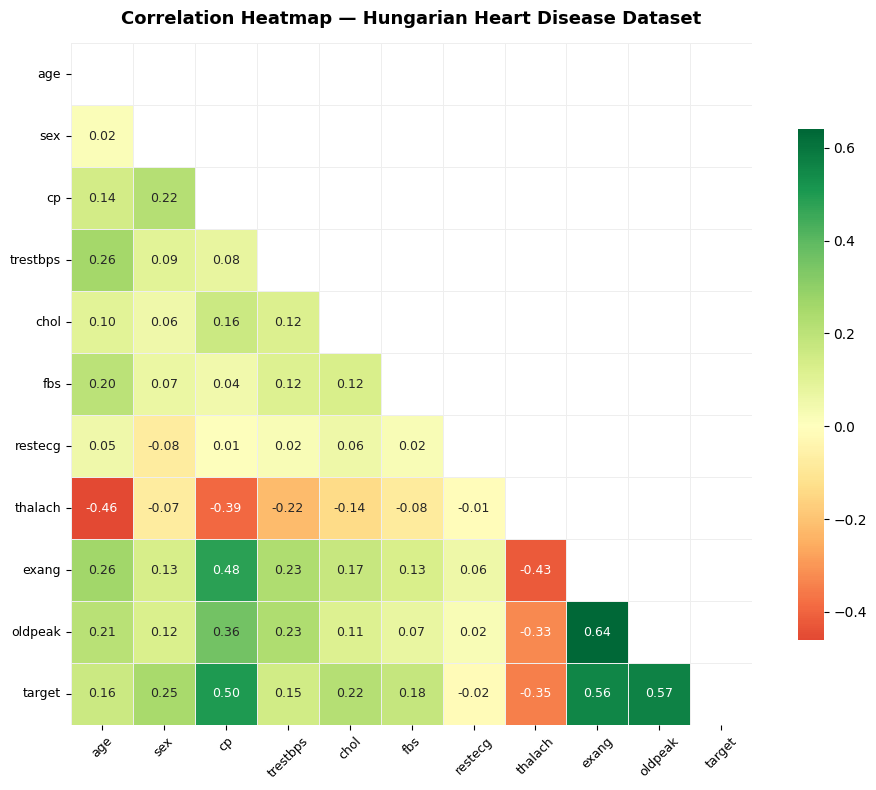

Heatmap saved as heatmap.png


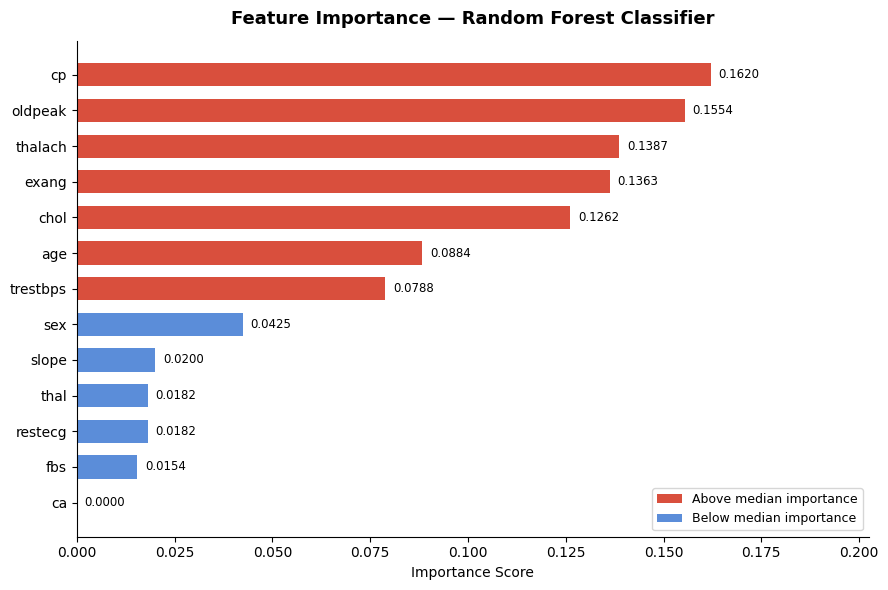

Feature importance chart saved as feature_importance.png


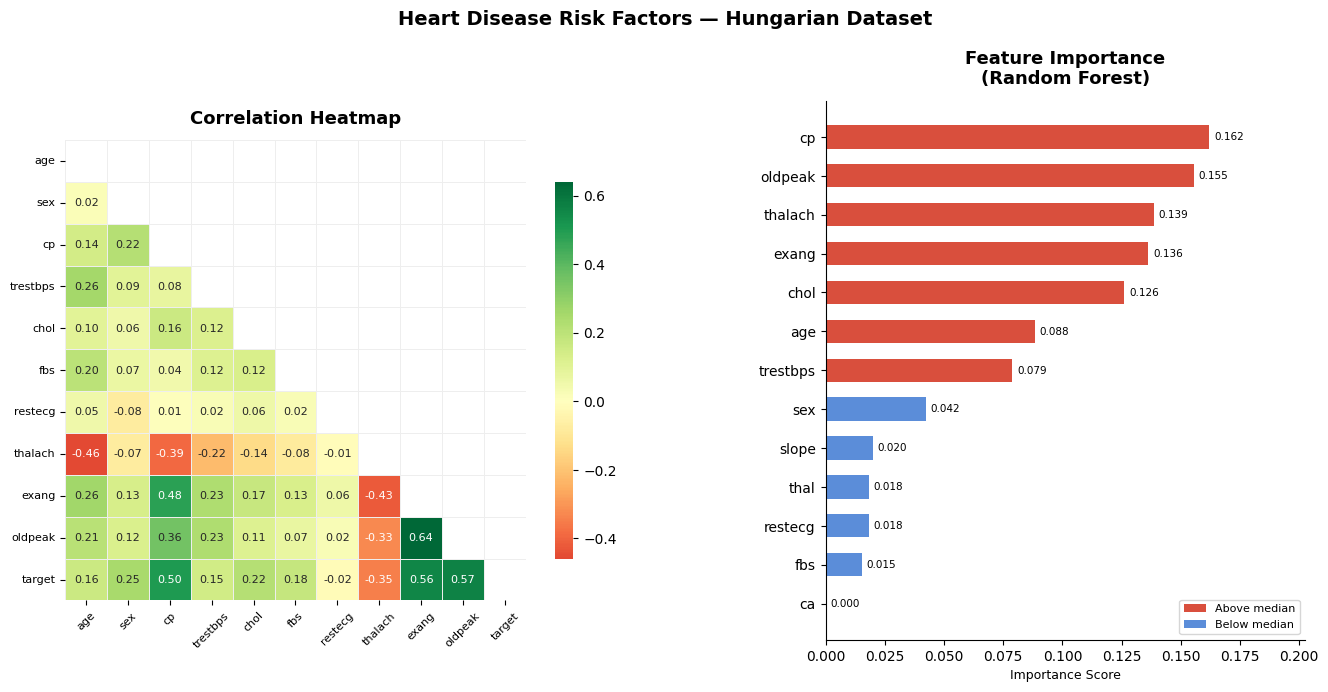

Combined figure saved as heart_disease_risk_factors.png
Feature Importance Ranking:


,Feature,Importance Score,Rank
0,Chest Pain Type,0.1620,1
1,ST Depression,0.1554,2
2,Max Heart Rate,0.1387,3
3,Exercise Angina,0.1363,4
4,Cholesterol,0.1262,5
5,Age,0.0884,6
6,Resting Blood Pressure,0.0788,7
7,Sex,0.0425,8
8,Slope,0.0200,9
9,Thal,0.0182,10


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully.')
# Column names for Hungarian Heart Disease dataset
cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

# Read raw file (each row is quoted as a single string)
with open('processed.hungarian.csv', 'r') as f:
    lines = f.readlines()

rows = []
for line in lines:
    line = line.strip().strip('"')
    rows.append(line.split(','))

df = pd.DataFrame(rows, columns=cols)

# Replace '?' (missing marker) with NaN and convert to numeric
df.replace('?', np.nan, inplace=True)
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing target; binarise target (0 = no disease, 1 = disease)
df.dropna(subset=['target'], inplace=True)
df['target'] = (df['target'] > 0).astype(int)

print(f'Dataset shape: {df.shape}')
print(f"Target distribution:\n{df['target'].value_counts().rename({0:'No Disease', 1:'Disease'})}")
df.head()
print('Missing values per column:')
print(df.isnull().sum())
print()
df.describe().round(2)
# Use columns with sufficient non-null values
heatmap_cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','target']
df_heat = df[heatmap_cols].dropna()

corr = df_heat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.5, linecolor='#eee',
    annot_kws={'size': 9}, square=True,
    cbar_kws={'shrink': 0.75}
)
ax.set_title('Correlation Heatmap — Hungarian Heart Disease Dataset', fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved as heatmap.png')
# Fill remaining NaN with median for model training
df_model = df.copy()
for col in cols[:-1]:
    df_model[col] = df_model[col].fillna(df_model[col].median())

X = df_model[cols[:-1]]
y = df_model['target']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=cols[:-1]).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d94f3d' if v >= importances.median() else '#5b8dd9' for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='none', height=0.65)

ax.set_title('Feature Importance — Random Forest Classifier', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, importances.max() * 1.25)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=8.5)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#d94f3d', label='Above median importance'),
    Patch(facecolor='#5b8dd9', label='Below median importance')
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance chart saved as feature_importance.png')
fig = plt.figure(figsize=(16, 7), facecolor='white')
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1], wspace=0.35)

# Left: Heatmap
ax1 = fig.add_subplot(gs[0])
importances_sorted = pd.Series(rf.feature_importances_, index=cols[:-1]).sort_values(ascending=True)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax1, linewidths=0.5, linecolor='#eee',
            annot_kws={'size': 8}, square=True, cbar_kws={'shrink': 0.7})
ax1.set_title('Correlation Heatmap', fontsize=13, fontweight='bold', pad=12)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', rotation=0, labelsize=8)

# Right: Feature Importance
ax2 = fig.add_subplot(gs[1])
colors2 = ['#d94f3d' if v >= importances_sorted.median() else '#5b8dd9' for v in importances_sorted.values]
bars2 = ax2.barh(importances_sorted.index, importances_sorted.values, color=colors2, edgecolor='none', height=0.6)
ax2.set_title('Feature Importance\n(Random Forest)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Importance Score', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlim(0, importances_sorted.max() * 1.25)
for bar, val in zip(bars2, importances_sorted.values):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left', fontsize=7.5)
ax2.legend(handles=[
    Patch(facecolor='#d94f3d', label='Above median'),
    Patch(facecolor='#5b8dd9', label='Below median')
], fontsize=8, loc='lower right')

fig.suptitle('Heart Disease Risk Factors — Hungarian Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('heart_disease_risk_factors.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Combined figure saved as heart_disease_risk_factors.png')
feature_labels = {
    'age': 'Age', 'sex': 'Sex', 'cp': 'Chest Pain Type',
    'trestbps': 'Resting Blood Pressure', 'chol': 'Cholesterol',
    'fbs': 'Fasting Blood Sugar', 'restecg': 'Resting ECG',
    'thalach': 'Max Heart Rate', 'exang': 'Exercise Angina',
    'oldpeak': 'ST Depression', 'slope': 'Slope', 'ca': 'CA', 'thal': 'Thal'
}

importances_desc = pd.Series(rf.feature_importances_, index=cols[:-1]).sort_values(ascending=False)
summary = pd.DataFrame({
    'Feature': [feature_labels.get(f, f) for f in importances_desc.index],
    'Importance Score': importances_desc.values.round(4),
    'Rank': range(1, len(importances_desc)+1)
})
print('Feature Importance Ranking:')
summary